0: 0.25 1: 1.00 2: 0.25 
0: 0.12 1: 0.78 2: 0.95 3: 0.33 
0: 0.06 1: 0.47 2: 0.91 3: 0.96 4: 0.58 


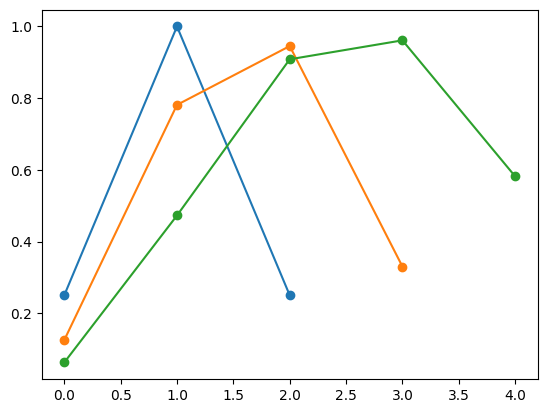

In [38]:
import matplotlib.pyplot as plt
import numpy as np
def get_amp_t(N,k):
    theta = np.arcsin(1 / np.sqrt(N))
    return np.sin((2*k+1)*theta) **2
for n in [2,3,4]:
    N = 2**n
    m_list = np.array(list(range(0,n+1)))
    prob = get_amp_t(N,m_list)
    print("".join([f"{i}: {p:.2f} "  for i,p in enumerate(prob)]))
    plt.plot(m_list,prob,marker='o')

In [2]:
from qiskit import QuantumCircuit, Aer, execute
from qiskit.aer import noise
from qiskit.visualization import plot_histogram
import math

def grover_circuit(n, marked_item):
    """Creates a Grover's search circuit for n qubits."""

    qc = QuantumCircuit(n, n)

    # Initialize qubits in superposition
    qc.h(range(n))

    # Grover iterations
    iterations = int(math.pi / 4 * math.sqrt(2**n))
    for _ in range(iterations):
        # Oracle
        if marked_item == 0:
            qc.x(range(n))
        qc.h(n-1)
        qc.mct(list(range(n-1)), n-1)  # Multi-controlled-Toffoli gate
        qc.h(n-1)
        if marked_item == 0:
            qc.x(range(n))

        # Diffusion operator
        qc.h(range(n))
        qc.x(range(n))
        qc.h(n-1)
        qc.mct(list(range(n-1)), n-1)  # Multi-controlled-Toffoli gate
        qc.h(n-1)
        qc.x(range(n))
        qc.h(range(n))

    # Measure the qubits
    qc.measure(range(n), range(n))

    return qc

# Simulate with noise
def simulate_with_noise(circuit):
    """Simulates the circuit with a depolarizing noise model."""

    noise_model = noise.NoiseModel()
    error_1 = noise.depolarizing_error(0.01, 1)
    error_2 = noise.depolarizing_error(0.01, 2)
    noise_model.add_all_qubit_quantum_error(error_1, ['u1', 'u2', 'u3'])
    noise_model.add_all_qubit_quantum_error(error_2, ['cx'])

    backend = Aer.get_backend('qasm_simulator')
    job = execute(circuit, backend, noise_model=noise_model)
    result = job.result()
    counts = result.get_counts()
    return counts

# Example usage
n = 3  # Number of qubits
marked_item = 5  # Item to search for (0 to 7)

circuit = grover_circuit(n, marked_item)
counts = simulate_with_noise(circuit)

# Plot the results
plot_histogram(counts)

ImportError: cannot import name 'Aer' from 'qiskit' (/Users/jiakaiwang/miniconda3/envs/qiskit/lib/python3.10/site-packages/qiskit/__init__.py)

Text(0, 0.5, 'Success Probability')

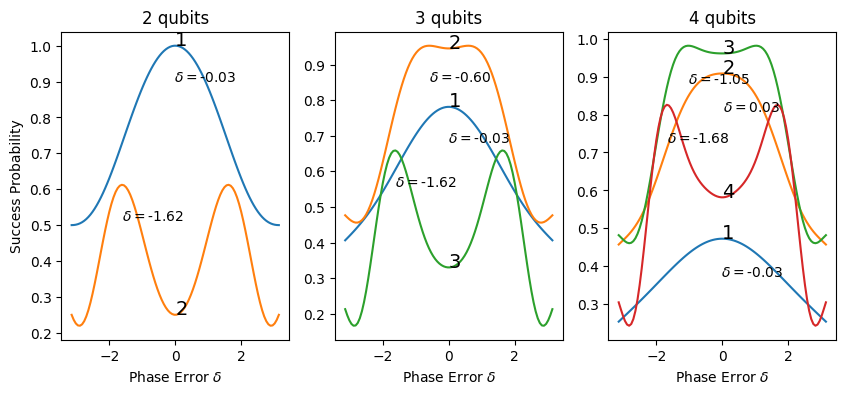

In [4]:
import numpy as np
from qutip import *
import matplotlib.pyplot as plt
def Hadamard(n_q):
    H = (1 / np.sqrt(2)) * Qobj([[1, 1], [1, -1]])
    return tensor([H for _ in range(n_q)])
def x(n_q):
    return tensor([Qobj([[0, 1], [1, 0]]) for _ in range(n_q)])
def CkRZ(n_q,delta):
    return qutip.Qobj(np.diag(np.array([1 for _ in range(2**n_q-2)]+
                                       [1j*np.exp(-1j * (delta+np.pi)/2) ]+
                                       [1j*np.exp(1j * (delta+np.pi)/2) ])), 
                      dims=[[2 for _ in range(n_q)],[2 for _ in range(n_q)]])
def run_grovers_algorithm(n_q, delta, m):
    initial_state = tensor([ basis(2, 0) for _ in range(n_q)]) 
    initial_state = Hadamard(n_q)*initial_state

    state = initial_state
    for _ in range(m):
        # Add a phase to the last qubit
        state = CkRZ(n_q,delta) * state
        state = Hadamard(n_q) * x(n_q) * CkRZ(n_q,delta) * x(n_q) * Hadamard(n_q) * state
    sucess_prob = np.abs(state[-1]).flatten()[0]**2
    return sucess_prob

delta_arr = np.linspace(-np.pi, np.pi, 100)
fig, axes = plt.subplots(1,3,figsize=(10, 4))
for n,ax in zip([2,3,4],axes):
    for m in range(1,n+1):
        sucess_for_delta = []
        for d in delta_arr:
            sucess_for_delta.append(run_grovers_algorithm(n, d, m))
        ax.plot(delta_arr, sucess_for_delta, label=f'm = {m}')
        ax.text(0,sucess_for_delta[int(len(sucess_for_delta)/2)],f'{m}',fontsize=14)
        ax.text(delta_arr[np.argmax(sucess_for_delta)], np.max(sucess_for_delta)-0.1,
                 rf"$\delta = ${delta_arr[np.argmax(sucess_for_delta)]:.2f}")
    ax.set_title(f"{n} qubits")
    ax.set_xlabel(r'Phase Error $\delta$')
axes[0].set_ylabel('Success Probability')